In [8]:
library(stringr)
library(gprofiler2)
library(rrvgo)
library(ggplot2)

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 100)


dev_files <- list.files('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/', '.txt')
dev_gs <- c()
for(fl in dev_files){
  dev_g <- read.table(paste0('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/',fl),header = T)
  cell_type <- gsub('\\.txt|-','',fl)
  dev_g$celltype <- cell_type
  dev_gs <- rbind(dev_g,dev_gs)
}

table(dev_gs$celltype)


     Astro        ID2   L23_CUX2    L4_RORB L56_THEMIS   L56_TLE4 LAMP5_NOS1 
      3497       3755       8842       8885       6924       7239       2514 
     Micro       Olig        OPC         PV  PV_SCUBE3        SST        VIP 
        58       2540       1321       5558       2745       4377       4624 

In [9]:
load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')
table(DEG_trend_Olf$trend_class)

load('./data/custom_olfbg.RData')
load('./data/lister_brain_bg.RData')



    down trans_up       up 
     602      389      785 

In [10]:

p_hp <- NULL
p_hp1 <- NULL
pattern <- c('down','up','trans_up')
for(PT in pattern) {
    for (CT in unique(dev_gs$celltype)){
        bg <- intersect(brain_bg,custom_olfbg )#union(brain_bg,custom_olfbg )
        
        CEN <- intersect(bg,subset(dev_gs, trend_class==PT & celltype==CT)[,"gene_name"])
        osn <- intersect(bg,subset(DEG_trend_Olf,trend_class==PT )[,"gene"])
        overlap <- intersect(CEN, osn)
        
        #bg <- custom_olfbg
        pval <- phyper(length(overlap) - 1, length(CEN), length(bg) - length(CEN), length(osn), lower.tail = FALSE)
        p_hp1 <- rbind(p_hp1, c(PT,CT, pval ))
        
        mat <- matrix(c(length(overlap),
                length(osn) - length(overlap),
                length(CEN) - length(overlap),
                length(bg) - length(osn) - length(CEN) + length(overlap)), 
              nrow = 2)
        res <- fisher.test(mat, alternative = "greater")

        p_hp <- rbind(p_hp, c(PT,CT, length(overlap),length(osn), res$p.value,res$estimate ))
    }

}

p_hp <- as.data.frame(p_hp)
p_hp$fdr <- p.adjust(as.numeric(p_hp$V5), method = 'fdr' )
colnames(p_hp) <- c('trend','CEN','N_overlap','N_osn','p','OR','FDR')
p_hp$Prop <- as.numeric(p_hp$N_overlap)/as.numeric(p_hp$N_osn)

In [11]:
#p_hp

In [12]:
#ggplot(subset(p_hp), aes(x=trend, y=-log10(FDR), size=as.numeric(`OR`), color=CEN))+geom_point()

pdf 
  2

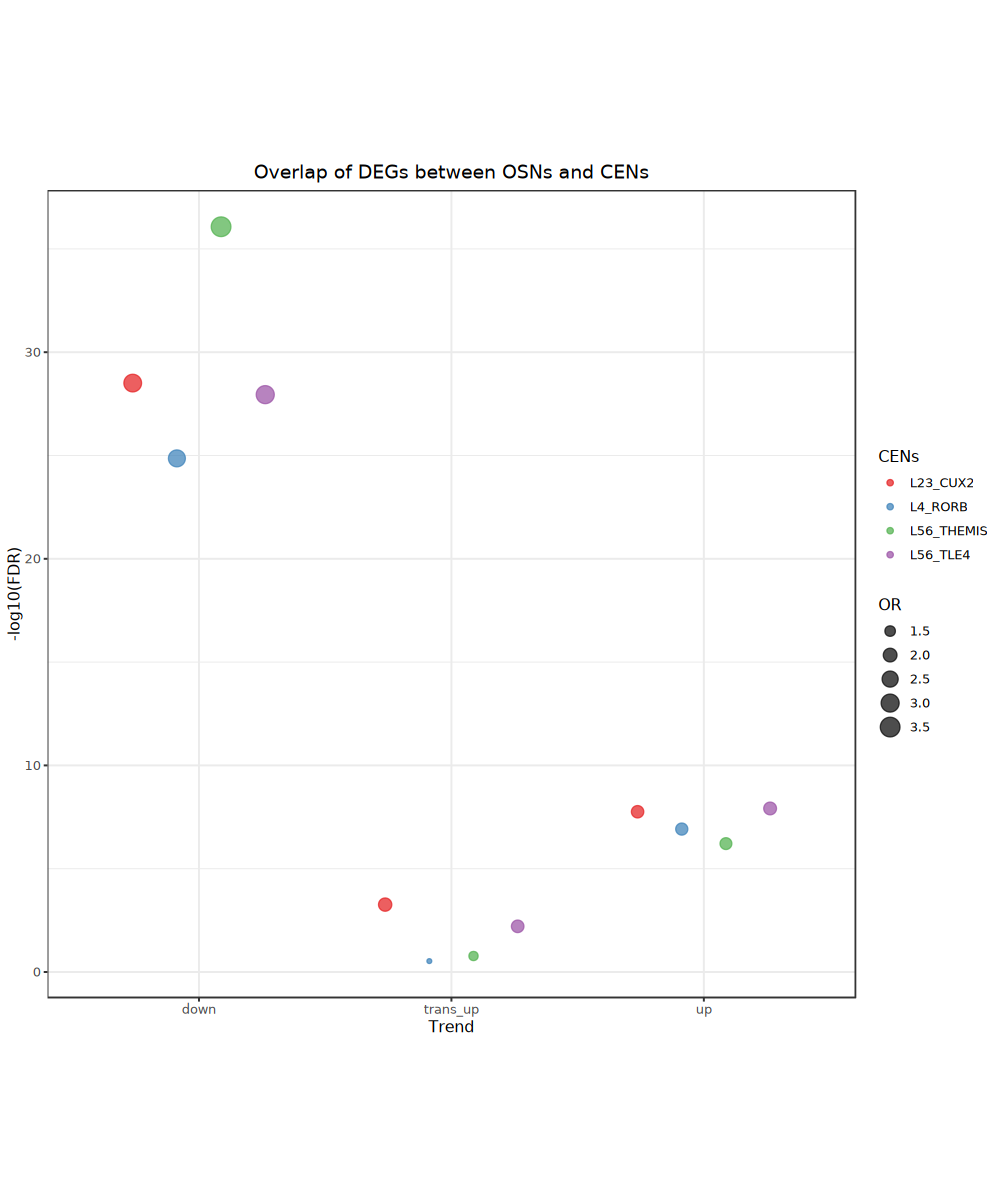

In [16]:
library(ggplot2)

df <- subset(p_hp, grepl('^L[0-9]', CEN))
df$OR <- as.numeric(df$OR)

ggplot(df, aes(
  x     = trend,
  y     = -log10(FDR),
  color = CEN
)) +
  geom_point(aes(size = OR),
             position = position_dodge(width = 0.7),
             alpha = 0.7) +
  #scale_size_continuous(range = c(2, 8), name = "Odds Ratio") +
  scale_color_brewer(palette = "Set1", name = "CENs") +
  labs(x = "Trend", y = "-log10(FDR)",
       title = "Overlap of DEGs between OSNs and CENs") +
  theme_bw() +
  theme(
    aspect.ratio =1,
    legend.position = "right",
    plot.title = element_text(hjust = 0.5)
  )

dev.print(pdf, file='./figures/DEG_overlap.pdf',height=5,width=5)

In [7]:
p_hp

trend,CEN,N_overlap,N_osn,p,OR,FDR,Prop
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
down,VIP,153,542,1.61590629134402e-31,3.57914592767662,1.131134e-30,0.282287823
down,SST,153,542,3.73455832729807e-34,3.81678160947062,3.137029e-33,0.282287823
down,PV,184,542,3.9614800096436e-35,3.51202367062225,4.159554e-34,0.339483395
down,PV_SCUBE3,121,542,1.87988447031833e-30,4.05718585366801,1.127931e-29,0.223247232
down,OPC,62,542,1.60462799545831e-23,5.63756212050438,5.616198e-23,0.114391144
down,Olig,80,542,5.62798347473227e-14,2.86767830905001,1.477346e-13,0.147601476
down,Micro,3,542,0.131814227681036,2.51282171762436,1.730062e-01,0.005535055
down,LAMP5_NOS1,113,542,3.26162473846261e-30,4.23962799867075,1.712353e-29,0.208487085
down,L56_TLE4,195,542,2.70016772129332e-29,3.01277679201855,1.134070e-28,0.359778598
